
# 03 — Dataset Quality Assurance

**Project:** Predicting neighbourhood deprivation from Google Street View imagery in Leeds  
**Unit of analysis:** One row per LSOA  
**Expected dataset:** 488 Leeds LSOAs  
**Purpose:** Audit the final aggregated SegFormer feature table and frozen spatial folds before nested spatial modelling.

This notebook performs:

1. Dataset overview and file-integrity checks  
2. Missing and non-finite value assessment  
3. Duplicate and identifier-integrity checks  
4. Summary statistics and plausible-range checks  
5. Semantic-feature distribution review  
6. Near-zero variance and zero-prevalence checks  
7. Correlation analysis  
8. Multicollinearity assessment using VIF where appropriate  
9. Deprivation-class balance  
10. Image coverage per LSOA  
11. Frozen spatial-fold quality checks  
12. Final QA decision and export of audit tables

> **Modelling boundary:** This notebook does not fit predictive models, select predictors using the target, standardise the full dataset for later reuse, fit PCA, resample classes, or regenerate spatial folds. All trainable preprocessing must occur inside nested spatial cross-validation.



## 1. Environment and configuration

The paths below match the final production SegFormer notebook. Change `PROJECT_DIR` only if the project has been moved.


In [1]:

from __future__ import annotations

from pathlib import Path
import hashlib
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    print("Google Drive mount skipped: this environment is not Google Colab.")

PROJECT_DIR = Path("/content/drive/MyDrive/leeds_gsv_project")
OUTPUT_DIR = PROJECT_DIR / "outputs_10points_metadata_once"
QA_DIR = OUTPUT_DIR / "dataset_quality_assurance"
QA_FIGURE_DIR = QA_DIR / "figures"

LSOA_FEATURE_FILE = OUTPUT_DIR / "segmentation_lsoa_features_19class_mean_sd.csv"
FOLD_MAP_FILE = OUTPUT_DIR / "lsoa_spatial_plus_fold_mapping.csv"
FOLD_AUDIT_FILE = OUTPUT_DIR / "spatial_plus_fold_audit.csv"
FOLD_FEATURE_BALANCE_FILE = OUTPUT_DIR / "spatial_plus_fold_feature_balance.csv"
RUN_SUMMARY_FILE = OUTPUT_DIR / "segmentation_run_summary.json"

QA_DIR.mkdir(parents=True, exist_ok=True)
QA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LSOA_ID_COL = "LSOA21CD"
TARGET_COL = "DeprivationClass"
CLASS_INDEX_COL = "ClassIdx"
FOLD_COL = "spatial_fold"
BLOCK_COL = "spatial_block"

EXPECTED_LSOAS = 488
EXPECTED_FOLDS = {1, 2, 3, 4, 5}
CORRELATION_FLAG_THRESHOLD = 0.90
NEAR_ZERO_VARIANCE_THRESHOLD = 1e-10
HIGH_ZERO_FRACTION_THRESHOLD = 0.95
VIF_FLAG_THRESHOLD = 10.0
SEMANTIC_SUM_TOLERANCE = 1e-6

CITYSCAPES_19 = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic_light", "traffic_sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]

GROUPED_FEATURES = [
    "green_natural_mean",
    "built_form_mean",
    "pedestrian_realm_mean",
    "road_transport_mean",
    "street_furniture_mean",
    "active_travel_people_mean",
    "sky_openness_mean",
]

print("QA output directory:", QA_DIR)



## 2. Load files and record checksums

Checksums allow the exact LSOA table and fold map used for modelling to be identified later.


In [2]:

required_files = [
    LSOA_FEATURE_FILE,
    FOLD_MAP_FILE,
    FOLD_AUDIT_FILE,
    FOLD_FEATURE_BALANCE_FILE,
]

missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Required files are missing:\n" + "\n".join(missing_files)
    )

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

file_manifest = pd.DataFrame(
    {
        "file": [str(path) for path in required_files],
        "sha256": [sha256_file(path) for path in required_files],
        "size_bytes": [path.stat().st_size for path in required_files],
    }
)

df = pd.read_csv(LSOA_FEATURE_FILE)
fold_map = pd.read_csv(FOLD_MAP_FILE)
fold_audit = pd.read_csv(FOLD_AUDIT_FILE)
fold_feature_balance = pd.read_csv(FOLD_FEATURE_BALANCE_FILE)

display(file_manifest)
print("LSOA feature-table shape:", df.shape)
print("Fold-map shape:", fold_map.shape)

file_manifest.to_csv(QA_DIR / "qa_file_manifest_sha256.csv", index=False)


                                                file  \
0  <PROJECT_DIR>/outpu...   
1  <PROJECT_DIR>/outpu...   
2  <PROJECT_DIR>/outpu...   
3  <PROJECT_DIR>/outpu...   

                                              sha256  size_bytes  
0  dc981747a7a7f884f623b2d4a396ec18adc2eaa96e5516...      815954  
1  7b83dba8bdb805a08e09da5cda2f135e875a727d5dedac...       55076  
2  ac12eacae502c75d35b49bae371ec17c34675c509d349b...         396  
3  110ec138e399a6fb4645833c059fdcb37f248d8bf362aa...        1235  

LSOA feature-table shape: (488, 102)
Fold-map shape: (488, 10)



## 3. Dataset overview

This section verifies the expected observational unit, target variables, folds, data types and feature families.


In [3]:

required_columns = [
    LSOA_ID_COL,
    "IMDRank",
    "IMDDecile",
    TARGET_COL,
    CLASS_INDEX_COL,
    BLOCK_COL,
    FOLD_COL,
]

missing_required_columns = [c for c in required_columns if c not in df.columns]
if missing_required_columns:
    raise KeyError(f"Missing required columns: {missing_required_columns}")

raw_semantic_features = [
    f"seg_{class_name}_mean" for class_name in CITYSCAPES_19
    if f"seg_{class_name}_mean" in df.columns
]
semantic_sd_features = [
    f"seg_{class_name}_std" for class_name in CITYSCAPES_19
    if f"seg_{class_name}_std" in df.columns
]
semantic_median_features = [
    f"seg_{class_name}_median" for class_name in CITYSCAPES_19
    if f"seg_{class_name}_median" in df.columns
]
clr_features = [
    f"clr_{class_name}" for class_name in CITYSCAPES_19
    if f"clr_{class_name}" in df.columns
]
grouped_features = [c for c in GROUPED_FEATURES if c in df.columns]

coverage_candidates = [
    "n_images_segmented",
    "n_sampling_points",
    "n_headings",
    "mean_segmentation_entropy",
    "sd_segmentation_entropy",
    "n_low_information_images",
    "low_information_fraction",
    "coverage_status",
]
coverage_features = [c for c in coverage_candidates if c in df.columns]

overview = pd.DataFrame(
    {
        "item": [
            "Rows",
            "Columns",
            "Unique LSOAs",
            "Raw semantic means",
            "Semantic SD features",
            "Semantic median features",
            "CLR features",
            "Grouped indicators",
            "Spatial blocks",
            "Spatial folds",
        ],
        "value": [
            len(df),
            df.shape[1],
            df[LSOA_ID_COL].nunique(dropna=False),
            len(raw_semantic_features),
            len(semantic_sd_features),
            len(semantic_median_features),
            len(clr_features),
            len(grouped_features),
            df[BLOCK_COL].nunique(dropna=False),
            df[FOLD_COL].nunique(dropna=False),
        ],
    }
)

display(overview)
display(df.head())
display(df.dtypes.astype(str).value_counts().rename_axis("dtype").to_frame("count"))

overview.to_csv(QA_DIR / "qa_dataset_overview.csv", index=False)


                       item  value
0                      Rows    488
1                   Columns    102
2              Unique LSOAs    488
3        Raw semantic means     19
4      Semantic SD features     19
5  Semantic median features     19
6              CLR features     19
7        Grouped indicators      7
8            Spatial blocks    120
9             Spatial folds      5

    LSOA21CD  IMDRank  IMDDecile  DeprivationClass  ClassIdx  seg_road_mean  \
0  E01035054    29778          9   Low Deprivation         2       0.325105   
1  E01011423     4973          2  High Deprivation         0       0.327906   
2  E01011268     6812          3  High Deprivation         0       0.275776   
3  E01033035     1856          1  High Deprivation         0       0.284325   
4  E01011339     5133          2  High Deprivation         0       0.302006   

   seg_sidewalk_mean  seg_building_mean  seg_wall_mean  seg_fence_mean  ...  \
0           0.062413           0.134347       0.014542        0.014422  ...   
1           0.032077           0.079579       0.006834        0.009990  ...   
2           0.023279           0.076686       0.004040        0.010356  ...   
3           0.060914           0.157918       0.010747        0.019481  ...   
4           0.022632           0.073024       0.003595        0.012654  ...   

    clr_bus  clr_train  clr_motorcycle  clr_bicycl

         count
dtype         
float64     90
int64        9
object       3


## 4. Missing and non-finite values

Both missing values and positive/negative infinity are checked. This is particularly important for CLR features, where incorrect zero handling could create infinite values.


In [4]:

missing_report = pd.DataFrame(
    {
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_percent": (100 * df.isna().mean()).values,
    }
).sort_values(["missing_count", "column"], ascending=[False, True])

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
infinite_counts = pd.Series(0, index=df.columns, dtype="int64")

if numeric_columns:
    infinite_counts.loc[numeric_columns] = np.isinf(
        df[numeric_columns].to_numpy(dtype=float)
    ).sum(axis=0)

nonfinite_report = missing_report.copy()
nonfinite_report["infinite_count"] = nonfinite_report["column"].map(infinite_counts)
nonfinite_report["total_nonfinite"] = (
    nonfinite_report["missing_count"] + nonfinite_report["infinite_count"]
)
nonfinite_report = nonfinite_report.sort_values(
    ["total_nonfinite", "column"], ascending=[False, True]
)

display(nonfinite_report.loc[nonfinite_report["total_nonfinite"] > 0])

if (nonfinite_report["total_nonfinite"] == 0).all():
    print("PASS: No missing or infinite values were detected.")
else:
    print("ACTION REQUIRED: Review all non-finite values before modelling.")

nonfinite_report.to_csv(QA_DIR / "qa_missing_and_nonfinite_values.csv", index=False)


Empty DataFrame
Columns: [column, missing_count, missing_percent, infinite_count, total_nonfinite]
Index: []

PASS: No missing or infinite values were detected.



## 5. Duplicate and identifier integrity

The final modelling table must contain exactly one row per LSOA. Each spatial micro-block must be assigned to only one frozen fold.


In [5]:

identifier_checks = {
    "row_count": int(len(df)),
    "unique_lsoa_count": int(df[LSOA_ID_COL].nunique(dropna=False)),
    "duplicate_lsoa_ids": int(df[LSOA_ID_COL].duplicated().sum()),
    "fully_duplicated_rows": int(df.duplicated().sum()),
    "missing_lsoa_ids": int(df[LSOA_ID_COL].isna().sum()),
    "missing_spatial_folds": int(df[FOLD_COL].isna().sum()),
    "folds_present": sorted(
        pd.to_numeric(df[FOLD_COL], errors="coerce").dropna().astype(int).unique().tolist()
    ),
    "maximum_folds_per_lsoa": int(
        df.groupby(LSOA_ID_COL, dropna=False)[FOLD_COL].nunique(dropna=False).max()
    ),
    "maximum_folds_per_block": int(
        df.groupby(BLOCK_COL, dropna=False)[FOLD_COL].nunique(dropna=False).max()
    ),
}

display(pd.Series(identifier_checks, name="result").to_frame())

assert len(df) == EXPECTED_LSOAS, (
    f"Expected {EXPECTED_LSOAS} LSOAs, found {len(df)}."
)
assert df[LSOA_ID_COL].nunique() == EXPECTED_LSOAS
assert df[LSOA_ID_COL].is_unique
assert df.duplicated().sum() == 0
assert df[LSOA_ID_COL].notna().all()
assert df[FOLD_COL].notna().all()
assert set(df[FOLD_COL].astype(int).unique()) == EXPECTED_FOLDS
assert df.groupby(LSOA_ID_COL)[FOLD_COL].nunique().max() == 1
assert df.groupby(BLOCK_COL)[FOLD_COL].nunique().max() == 1

print("PASS: LSOA identifiers and frozen spatial assignments are valid.")


                                  result
row_count                            488
unique_lsoa_count                    488
duplicate_lsoa_ids                     0
fully_duplicated_rows                  0
missing_lsoa_ids                       0
missing_spatial_folds                  0
folds_present            [1, 2, 3, 4, 5]
maximum_folds_per_lsoa                 1
maximum_folds_per_block                1

PASS: LSOA identifiers and frozen spatial assignments are valid.



## 6. Verify the exported fold map has not changed

The fold map is treated as authoritative and read-only. The assignments embedded in the feature table must agree exactly with the exported mapping.


In [6]:

fold_required = [LSOA_ID_COL, BLOCK_COL, FOLD_COL]
missing_fold_columns = [c for c in fold_required if c not in fold_map.columns]
if missing_fold_columns:
    raise KeyError(f"Fold map is missing: {missing_fold_columns}")

fold_compare = df[[LSOA_ID_COL, BLOCK_COL, FOLD_COL]].merge(
    fold_map[fold_required],
    on=LSOA_ID_COL,
    how="outer",
    validate="one_to_one",
    suffixes=("_features", "_map"),
    indicator=True,
)

block_match = (
    fold_compare[f"{BLOCK_COL}_features"].astype("Int64")
    == fold_compare[f"{BLOCK_COL}_map"].astype("Int64")
)
fold_match = (
    fold_compare[f"{FOLD_COL}_features"].astype("Int64")
    == fold_compare[f"{FOLD_COL}_map"].astype("Int64")
)

fold_map_check = {
    "merged_rows": int(len(fold_compare)),
    "nonmatching_keys": int((fold_compare["_merge"] != "both").sum()),
    "nonmatching_blocks": int((~block_match.fillna(False)).sum()),
    "nonmatching_folds": int((~fold_match.fillna(False)).sum()),
}

display(pd.Series(fold_map_check, name="result").to_frame())

assert fold_map_check["merged_rows"] == EXPECTED_LSOAS
assert fold_map_check["nonmatching_keys"] == 0
assert fold_map_check["nonmatching_blocks"] == 0
assert fold_map_check["nonmatching_folds"] == 0

print("PASS: Feature-table fold assignments exactly match the frozen fold map.")


                    result
merged_rows            488
nonmatching_keys         0
nonmatching_blocks       0
nonmatching_folds        0

PASS: Feature-table fold assignments exactly match the frozen fold map.



## 7. Summary statistics and plausible ranges

Raw semantic means must be bounded between 0 and 1. Because each image composition sums to one, the 19 aggregated LSOA semantic means should also sum to approximately one.


In [7]:

if len(raw_semantic_features) != 19:
    raise ValueError(
        f"Expected 19 raw semantic mean features, found {len(raw_semantic_features)}."
    )

summary_statistics = df.select_dtypes(include=[np.number]).describe().T
summary_statistics["missing_count"] = df[summary_statistics.index].isna().sum()
summary_statistics["unique_count"] = df[summary_statistics.index].nunique(dropna=True)
display(summary_statistics)

semantic_min = float(df[raw_semantic_features].min().min())
semantic_max = float(df[raw_semantic_features].max().max())
semantic_sum = df[raw_semantic_features].sum(axis=1)

semantic_checks = pd.Series(
    {
        "minimum_raw_semantic_proportion": semantic_min,
        "maximum_raw_semantic_proportion": semantic_max,
        "semantic_sum_min": float(semantic_sum.min()),
        "semantic_sum_max": float(semantic_sum.max()),
        "semantic_sum_mean": float(semantic_sum.mean()),
        "maximum_absolute_sum_error": float(np.abs(semantic_sum - 1.0).max()),
    },
    name="result",
)

display(semantic_checks.to_frame())

assert semantic_min >= -SEMANTIC_SUM_TOLERANCE
assert semantic_max <= 1 + SEMANTIC_SUM_TOLERANCE
assert np.allclose(
    semantic_sum.to_numpy(),
    1.0,
    atol=SEMANTIC_SUM_TOLERANCE,
    rtol=0,
)

print("PASS: Semantic proportions have valid ranges and sum to one.")
summary_statistics.to_csv(QA_DIR / "qa_numeric_summary_statistics.csv")
semantic_sum.rename("semantic_proportion_sum").to_csv(
    QA_DIR / "qa_semantic_proportion_sums.csv",
    index_label=LSOA_ID_COL,
)


                          count          mean           std          min  \
IMDRank                   488.0  16564.456967  10956.893568    58.000000   
IMDDecile                 488.0      5.418033      3.226151     1.000000   
ClassIdx                  488.0      0.981557      0.839030     0.000000   
seg_road_mean             488.0      0.295776      0.025993     0.135313   
seg_sidewalk_mean         488.0      0.041020      0.010696     0.006386   
...                         ...           ...           ...          ...   
low_information_fraction  488.0      0.000679      0.004417     0.000000   
x_km                      488.0   -101.877344      5.718497  -114.973349   
y_km                      488.0   5949.994733      4.795080  5939.538637   
spatial_block             488.0     47.217213     33.307077     0.000000   
spatial_fold              488.0      2.991803      1.414190     1.000000   

                                  25%           50%           75%  \
IMDRank           

                                       result
minimum_raw_semantic_proportion  0.000000e+00
maximum_raw_semantic_proportion  4.092877e-01
semantic_sum_min                 1.000000e+00
semantic_sum_max                 1.000000e+00
semantic_sum_mean                1.000000e+00
maximum_absolute_sum_error       9.992007e-16

PASS: Semantic proportions have valid ranges and sum to one.



## 8. Semantic-feature distributions

The plots below are descriptive QA outputs. Extreme values should be investigated in context rather than removed automatically.

The notebook saves figures to the QA figure directory so that only selected plots need to be shown in the dissertation.


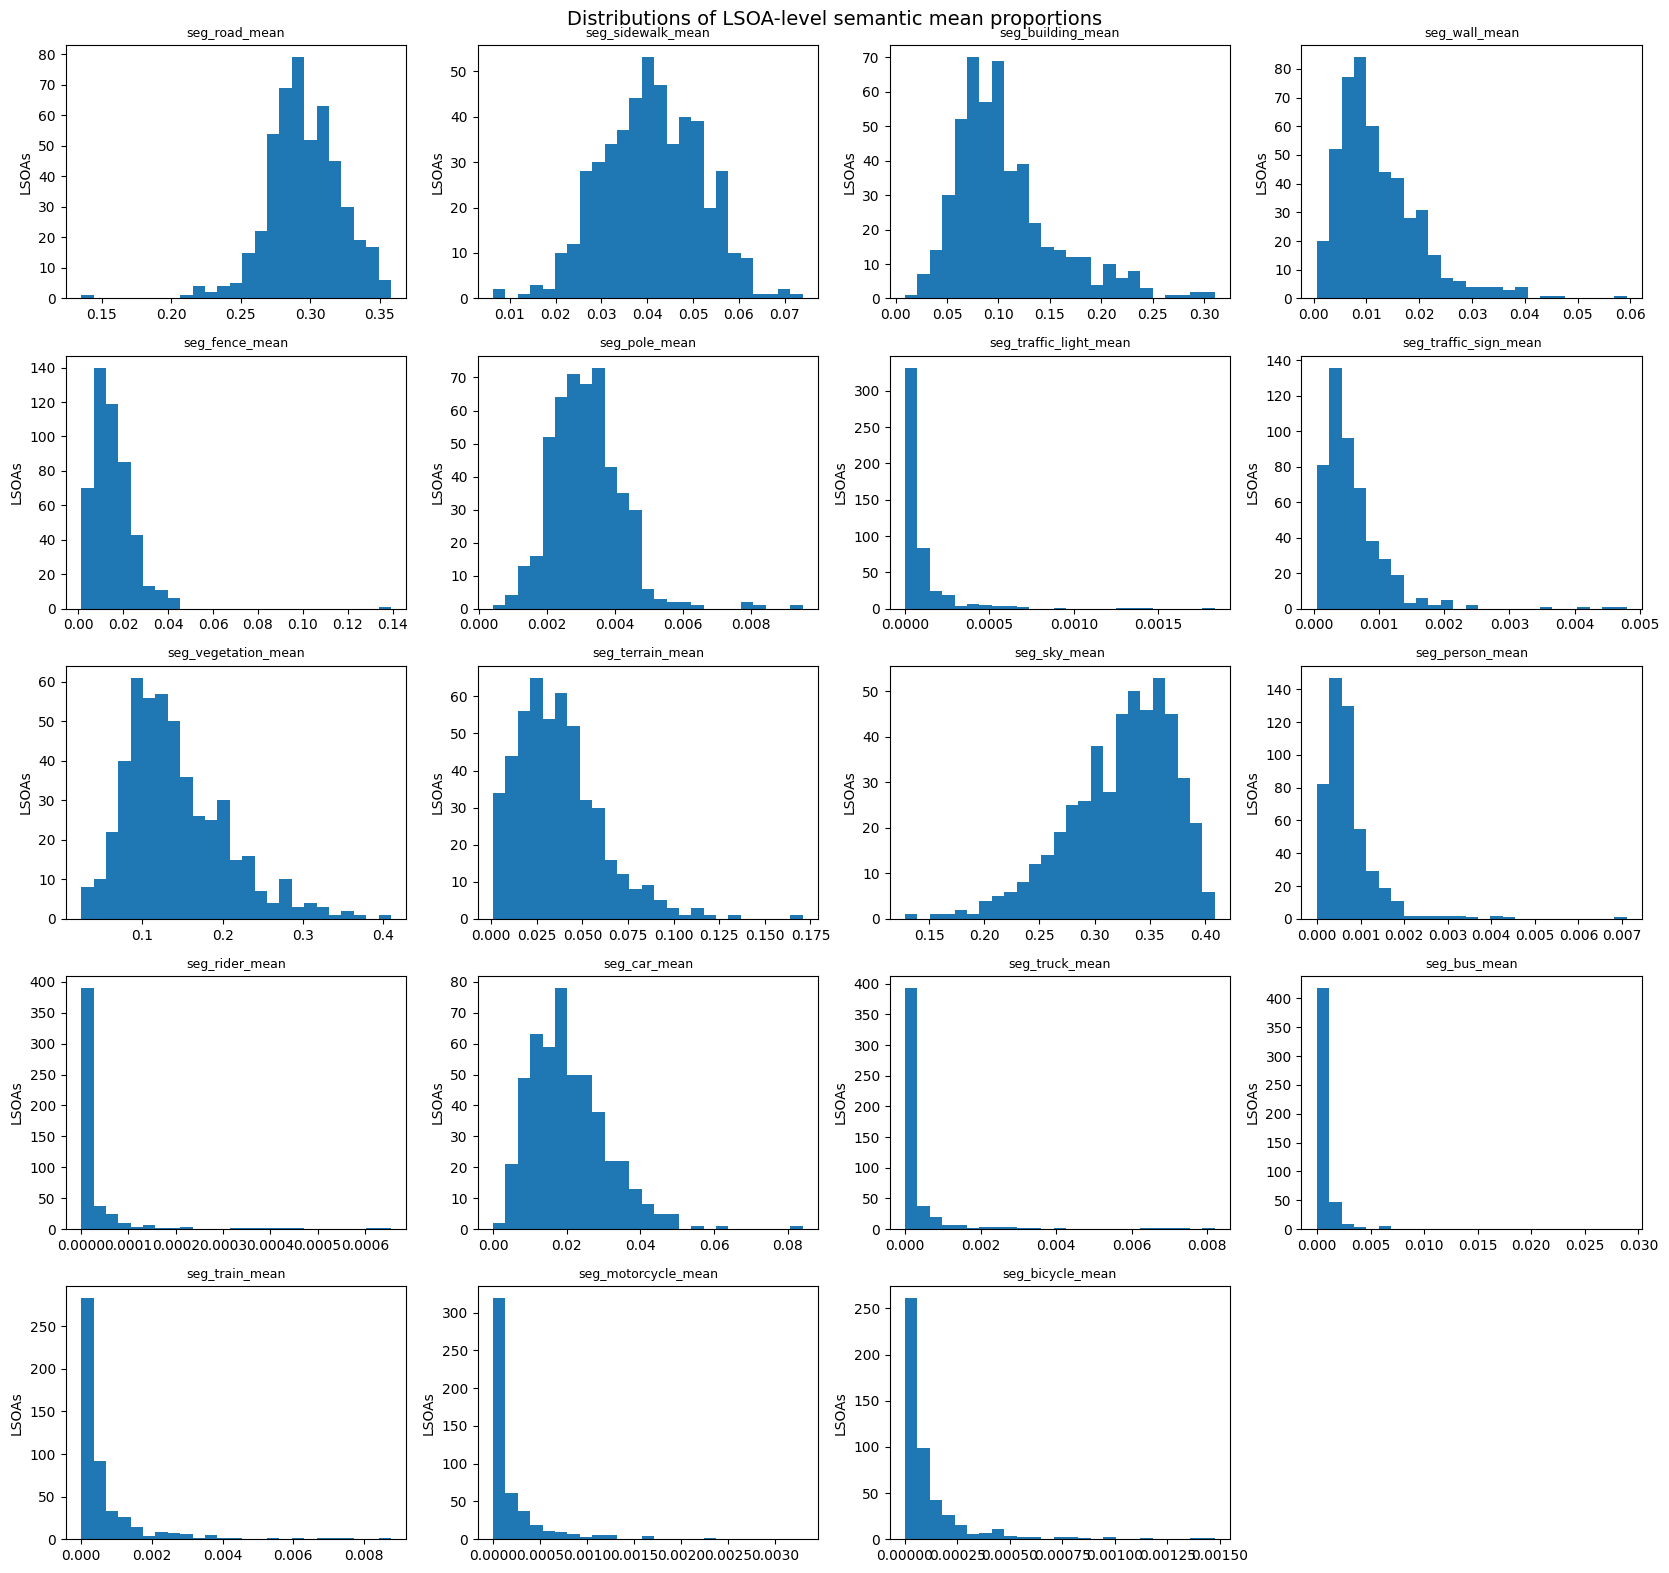

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/semantic_mean_histograms.png


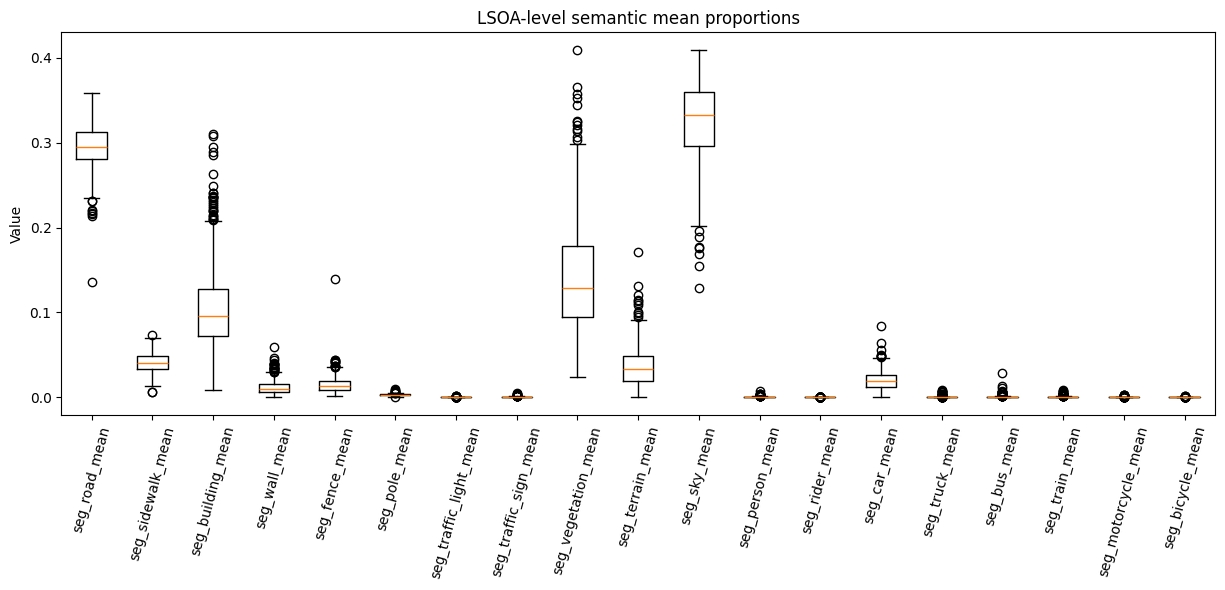

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/semantic_mean_boxplots.png


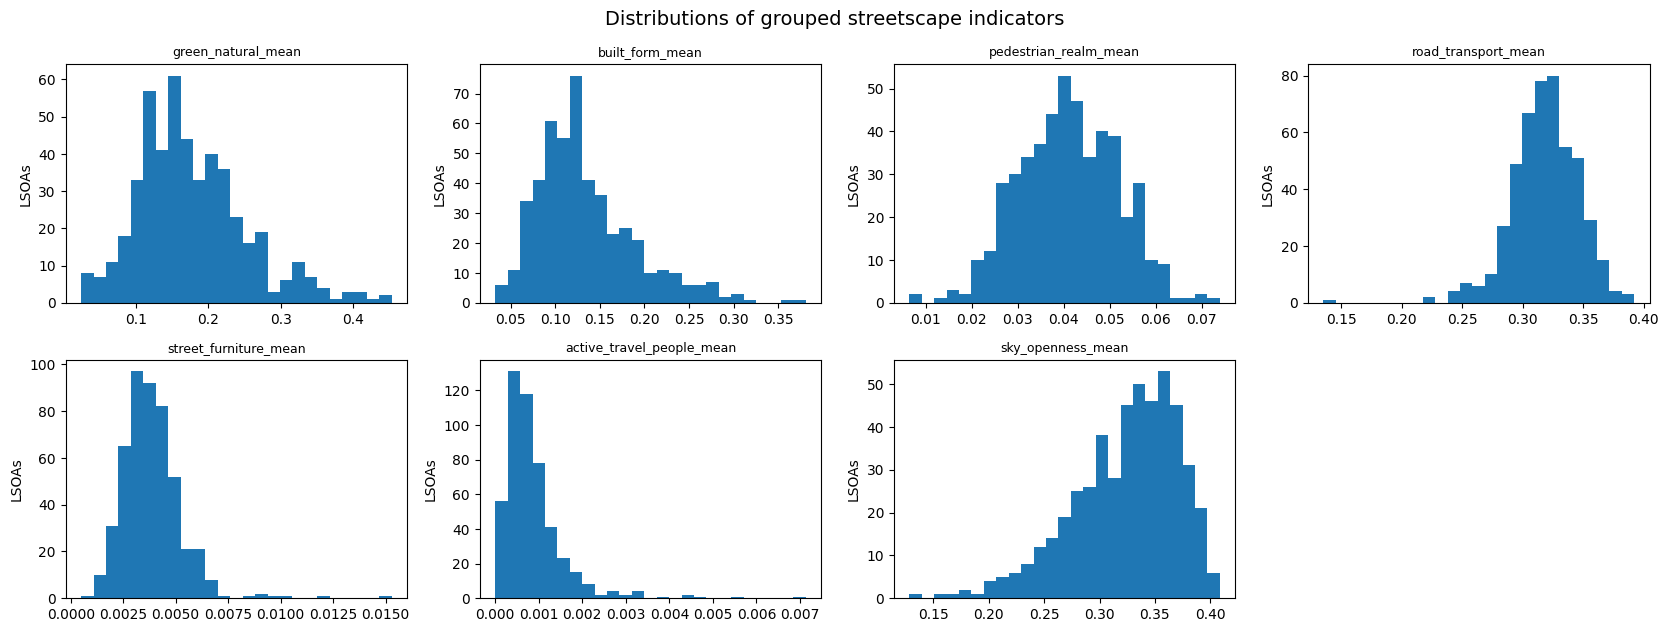

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/grouped_indicator_histograms.png


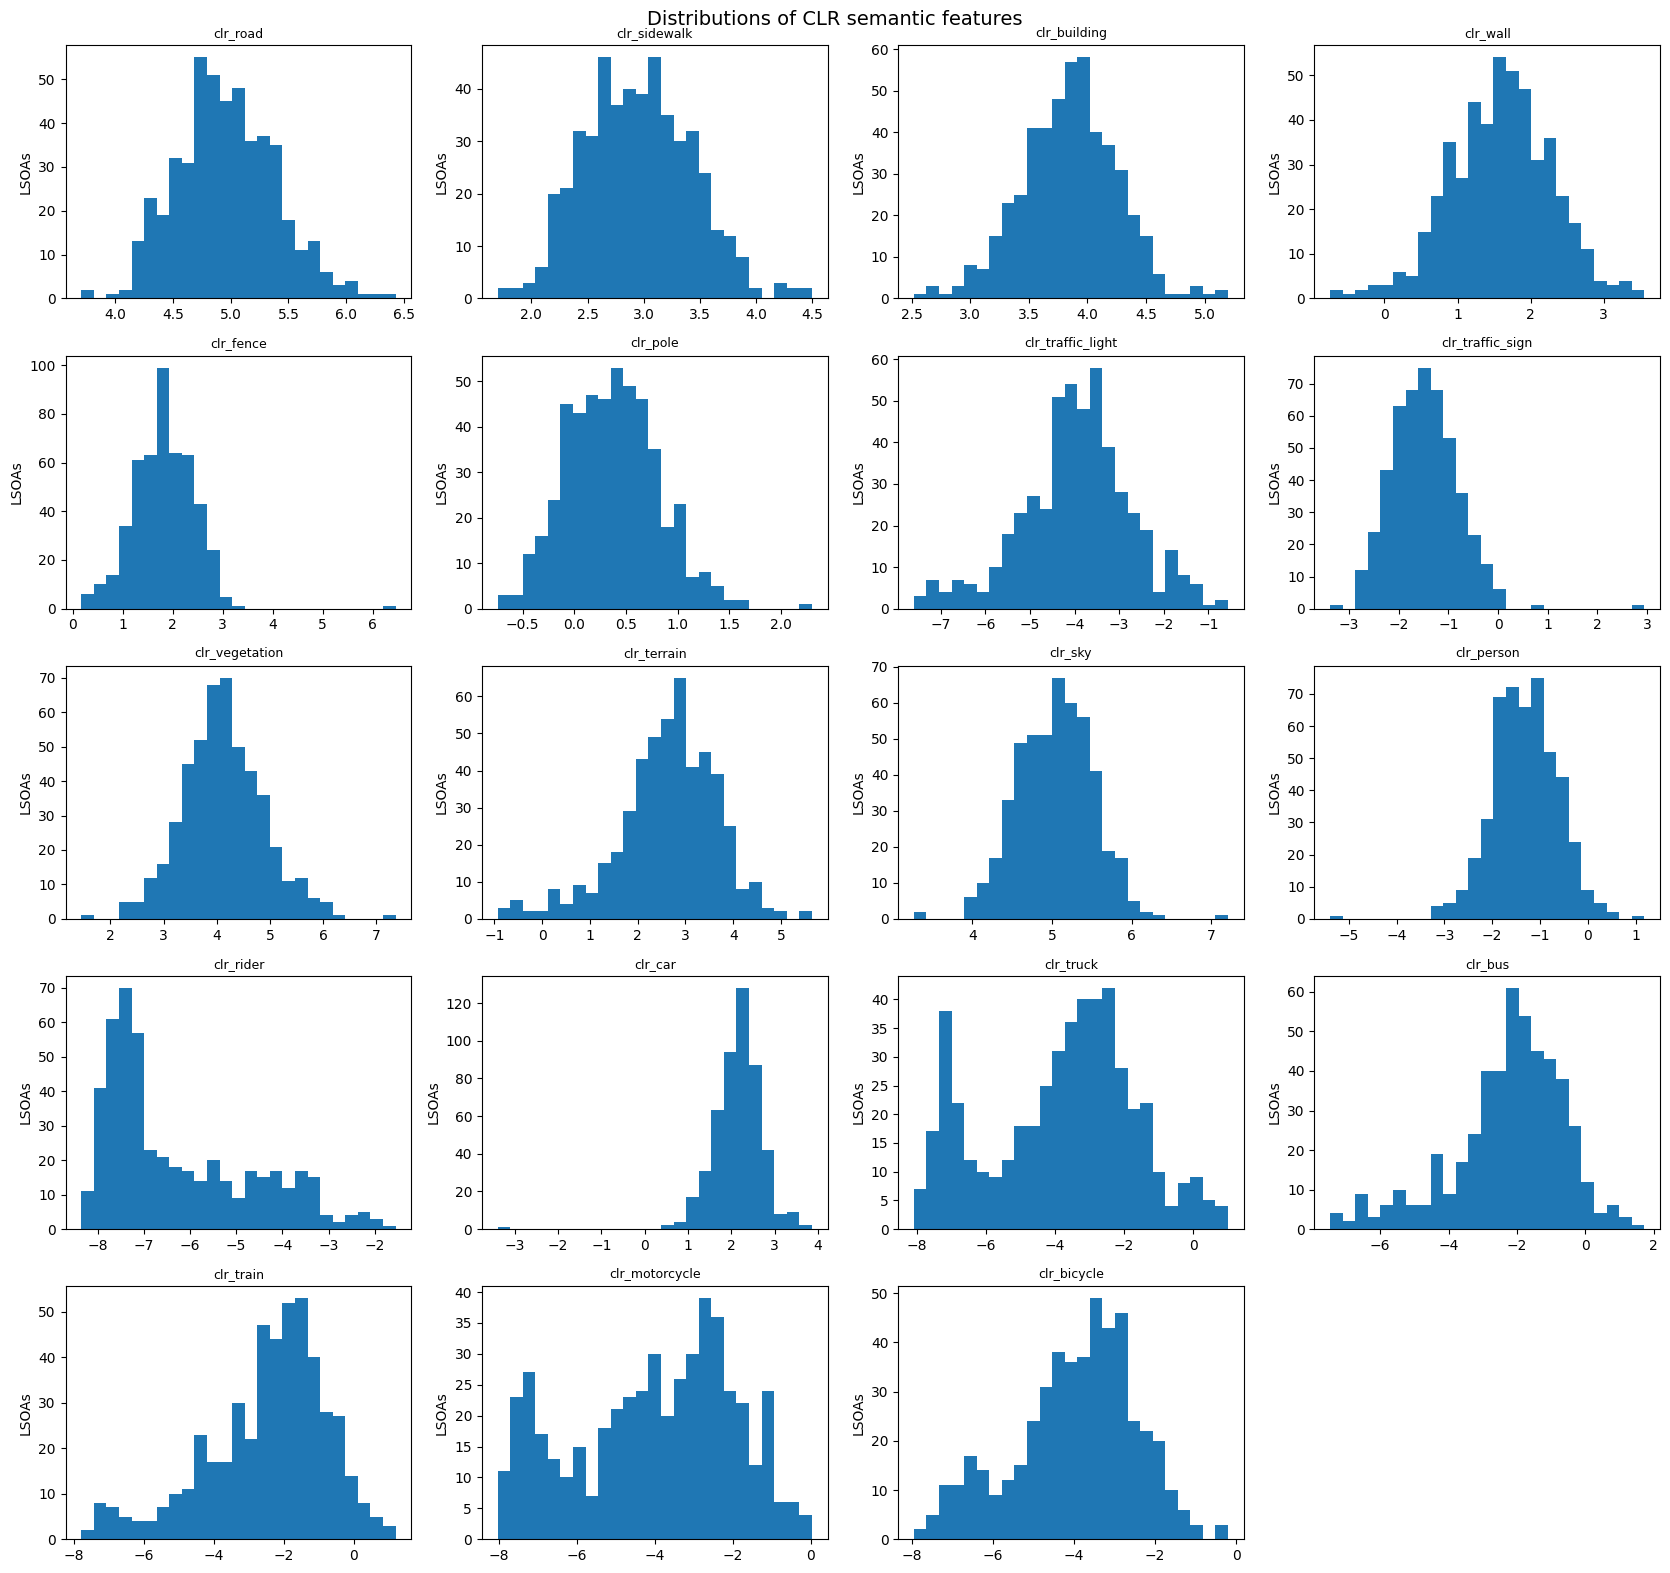

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/clr_feature_histograms.png


In [8]:

def save_histograms(
    frame: pd.DataFrame,
    columns: list[str],
    title_prefix: str,
    filename: str,
    bins: int = 25,
    columns_per_row: int = 4,
) -> None:
    if not columns:
        print(f"No columns available for {title_prefix}.")
        return

    n_cols = min(columns_per_row, len(columns))
    n_rows = math.ceil(len(columns) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 3.2 * n_rows),
        squeeze=False,
    )

    for axis, column in zip(axes.ravel(), columns):
        values = pd.to_numeric(frame[column], errors="coerce").dropna()
        axis.hist(values, bins=bins)
        axis.set_title(column, fontsize=9)
        axis.set_xlabel("")
        axis.set_ylabel("LSOAs")

    for axis in axes.ravel()[len(columns):]:
        axis.axis("off")

    fig.suptitle(title_prefix, fontsize=14)
    fig.tight_layout()
    path = QA_FIGURE_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def save_boxplots(
    frame: pd.DataFrame,
    columns: list[str],
    title: str,
    filename: str,
) -> None:
    if not columns:
        print(f"No columns available for {title}.")
        return

    fig, axis = plt.subplots(figsize=(max(12, len(columns) * 0.65), 6))
    data = [pd.to_numeric(frame[c], errors="coerce").dropna() for c in columns]
    axis.boxplot(data, tick_labels=columns, showfliers=True)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=75)
    axis.set_ylabel("Value")
    fig.tight_layout()

    path = QA_FIGURE_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


save_histograms(
    df,
    raw_semantic_features,
    "Distributions of LSOA-level semantic mean proportions",
    "semantic_mean_histograms.png",
)

save_boxplots(
    df,
    raw_semantic_features,
    "LSOA-level semantic mean proportions",
    "semantic_mean_boxplots.png",
)

save_histograms(
    df,
    grouped_features,
    "Distributions of grouped streetscape indicators",
    "grouped_indicator_histograms.png",
)

save_histograms(
    df,
    clr_features,
    "Distributions of CLR semantic features",
    "clr_feature_histograms.png",
)



## 9. Near-zero variance, zero prevalence and rare features

Near-constant predictors may provide little discrimination. A large zero fraction is expected for rare Cityscapes classes, but it should be documented rather than silently ignored.


In [9]:

candidate_predictors = list(dict.fromkeys(
    raw_semantic_features + grouped_features + clr_features
))

feature_screen = pd.DataFrame(index=candidate_predictors)
feature_screen["variance"] = df[candidate_predictors].var(ddof=1)
feature_screen["standard_deviation"] = df[candidate_predictors].std(ddof=1)
feature_screen["unique_count"] = df[candidate_predictors].nunique(dropna=True)
feature_screen["zero_fraction"] = (df[candidate_predictors] == 0).mean()
feature_screen["near_zero_variance_flag"] = (
    feature_screen["variance"] <= NEAR_ZERO_VARIANCE_THRESHOLD
)
feature_screen["high_zero_fraction_flag"] = (
    feature_screen["zero_fraction"] >= HIGH_ZERO_FRACTION_THRESHOLD
)
feature_screen = feature_screen.sort_values(
    ["near_zero_variance_flag", "high_zero_fraction_flag", "variance"],
    ascending=[False, False, True],
)

display(feature_screen)

constant_features = feature_screen.index[
    feature_screen["unique_count"] <= 1
].tolist()

if constant_features:
    print("ACTION REQUIRED — constant features:", constant_features)
else:
    print("PASS: No constant candidate predictors were detected.")

feature_screen.to_csv(QA_DIR / "qa_feature_variance_and_zero_prevalence.csv")


                               variance  standard_deviation  unique_count  \
seg_rider_mean             4.848748e-09            0.000070           227   
seg_traffic_light_mean     2.984198e-08            0.000173           445   
seg_bicycle_mean           3.207352e-08            0.000179           436   
seg_motorcycle_mean        1.451721e-07            0.000381           400   
seg_traffic_sign_mean      2.649960e-07            0.000515           482   
seg_person_mean            4.172481e-07            0.000646           483   
active_travel_people_mean  5.346436e-07            0.000731           485   
seg_truck_mean             9.750392e-07            0.000987           408   
seg_pole_mean              1.077924e-06            0.001038           484   
seg_train_mean             1.092399e-06            0.001045           473   
street_furniture_mean      2.025714e-06            0.001423           487   
seg_bus_mean               3.169240e-06            0.001780           477   

PASS: No constant candidate predictors were detected.



## 10. Correlation analysis

Correlation is evaluated separately for the three planned predictor representations:

- raw semantic means;
- grouped environmental indicators;
- CLR semantic features.

This avoids conflating deliberately overlapping representations.


Empty DataFrame
Columns: [feature_1, feature_2, correlation, absolute_correlation]
Index: []

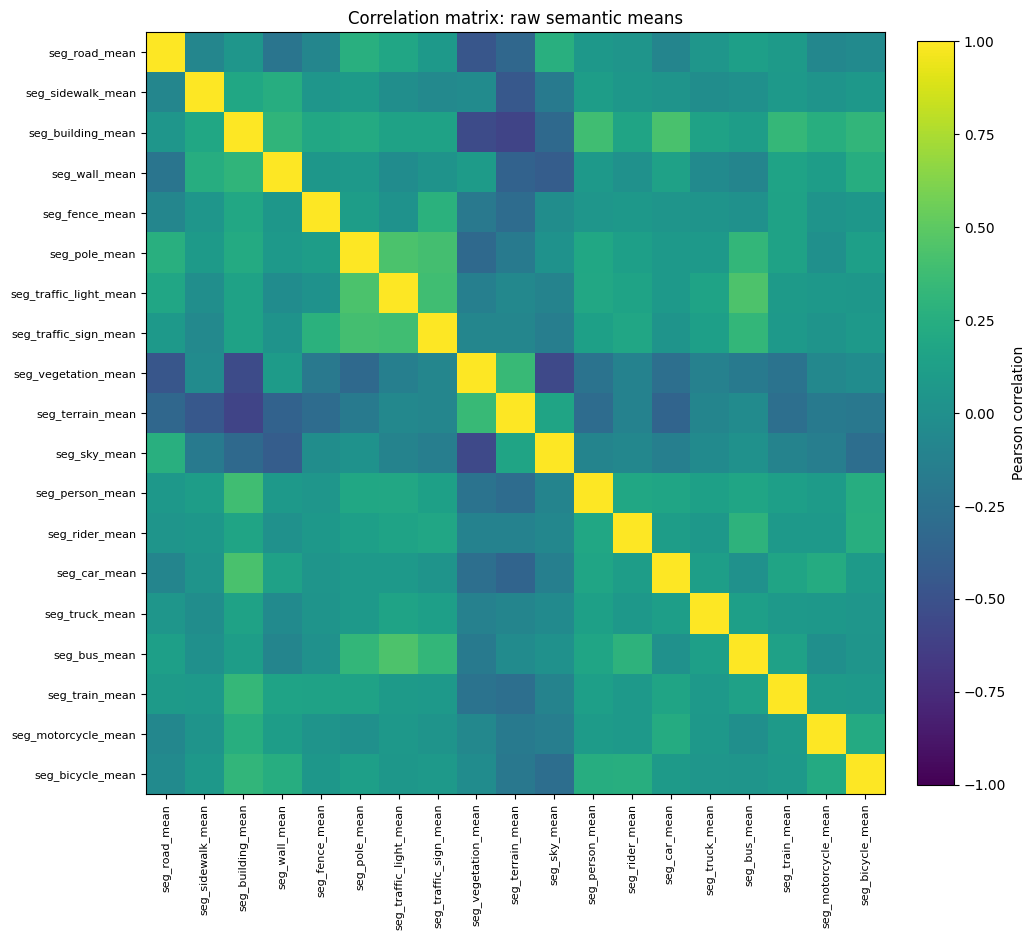

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/correlation_raw_semantic_means.png


Empty DataFrame
Columns: [feature_1, feature_2, correlation, absolute_correlation]
Index: []

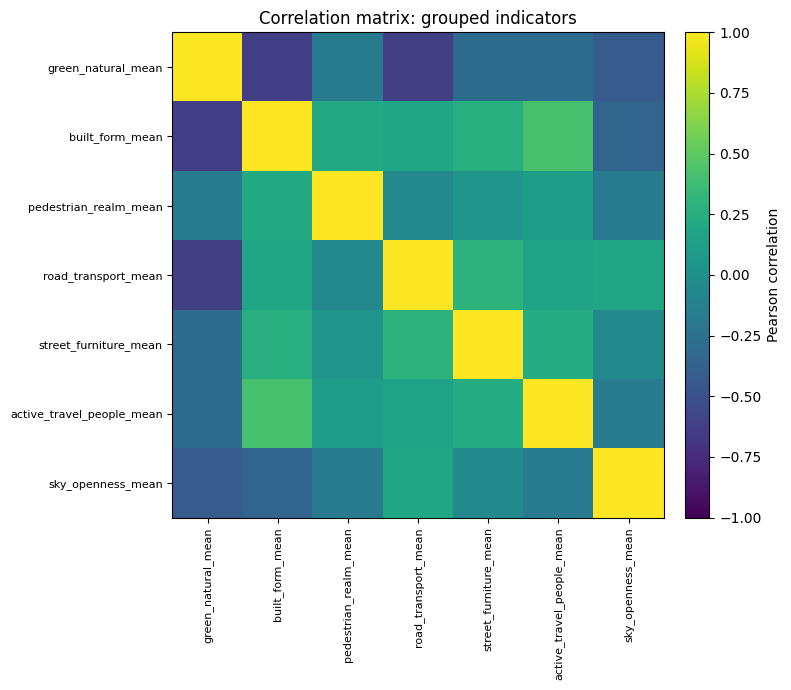

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/correlation_grouped_indicators.png


    feature_set feature_1 feature_2  correlation  absolute_correlation
9  clr_features  clr_road   clr_sky     0.935639              0.935639

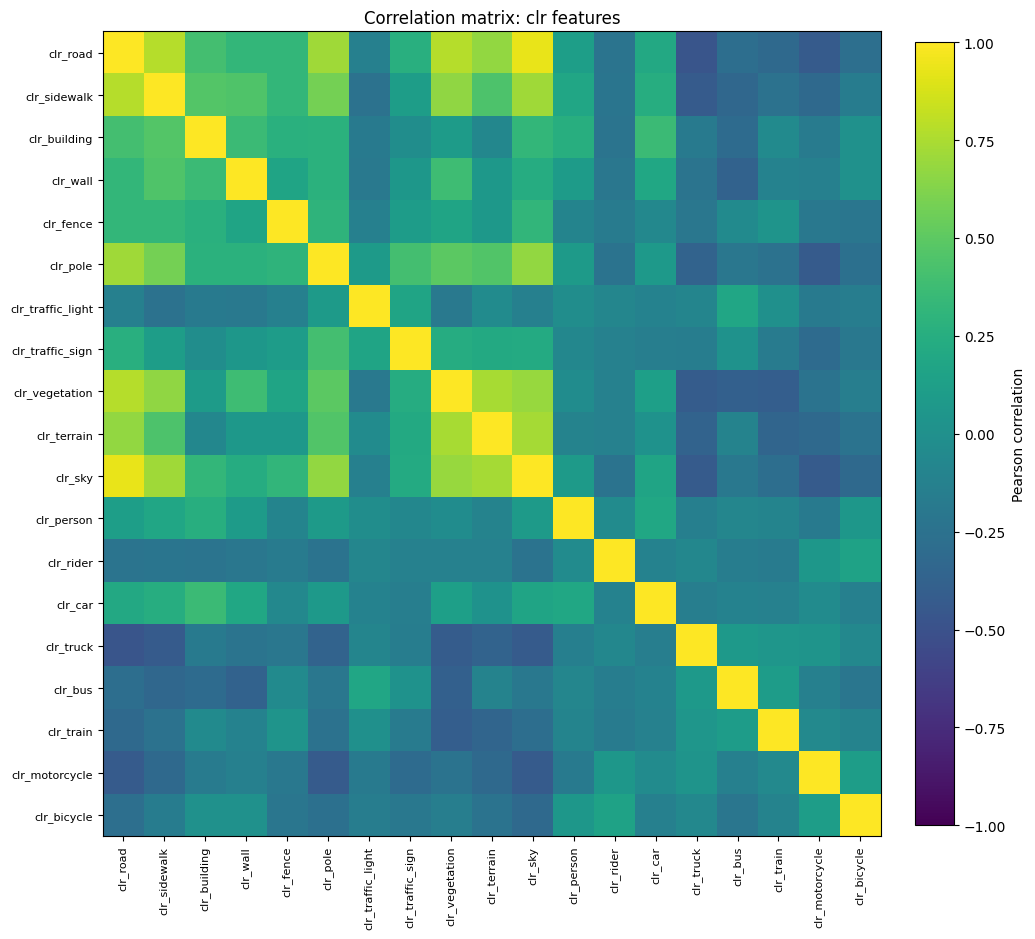

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/dataset_quality_assurance/figures/correlation_clr_features.png


In [10]:

def correlation_pairs(
    frame: pd.DataFrame,
    columns: list[str],
    threshold: float = CORRELATION_FLAG_THRESHOLD,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if len(columns) < 2:
        return pd.DataFrame(), pd.DataFrame()

    corr = frame[columns].corr(method="pearson")
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    pairs = (
        upper.stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    )
    pairs["absolute_correlation"] = pairs["correlation"].abs()
    pairs = pairs.sort_values("absolute_correlation", ascending=False)
    flagged = pairs.loc[pairs["absolute_correlation"] >= threshold].copy()
    return corr, flagged


def plot_correlation_matrix(
    corr: pd.DataFrame,
    title: str,
    filename: str,
) -> None:
    if corr.empty:
        return

    fig, axis = plt.subplots(
        figsize=(max(8, len(corr.columns) * 0.55), max(7, len(corr.columns) * 0.5))
    )
    image = axis.imshow(corr.to_numpy(), vmin=-1, vmax=1, aspect="auto")
    axis.set_xticks(np.arange(len(corr.columns)))
    axis.set_yticks(np.arange(len(corr.index)))
    axis.set_xticklabels(corr.columns, rotation=90, fontsize=8)
    axis.set_yticklabels(corr.index, fontsize=8)
    axis.set_title(title)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04, label="Pearson correlation")
    fig.tight_layout()

    path = QA_FIGURE_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


correlation_sets = {
    "raw_semantic_means": raw_semantic_features,
    "grouped_indicators": grouped_features,
    "clr_features": clr_features,
}

all_flagged_correlations = []

for set_name, columns in correlation_sets.items():
    corr, flagged = correlation_pairs(df, columns)
    corr.to_csv(QA_DIR / f"qa_correlation_matrix_{set_name}.csv")
    flagged.to_csv(
        QA_DIR / f"qa_high_correlations_{set_name}.csv",
        index=False,
    )

    if not flagged.empty:
        flagged.insert(0, "feature_set", set_name)
        all_flagged_correlations.append(flagged)

    display(flagged.head(30))
    plot_correlation_matrix(
        corr,
        title=f"Correlation matrix: {set_name.replace('_', ' ')}",
        filename=f"correlation_{set_name}.png",
    )

if all_flagged_correlations:
    flagged_correlations = pd.concat(all_flagged_correlations, ignore_index=True)
else:
    flagged_correlations = pd.DataFrame(
        columns=[
            "feature_set", "feature_1", "feature_2",
            "correlation", "absolute_correlation"
        ]
    )

flagged_correlations.to_csv(
    QA_DIR / "qa_all_high_correlation_pairs.csv",
    index=False,
)



## 11. Multicollinearity assessment using VIF

VIF is calculated for the **grouped indicator set**, where it has a straightforward interpretation.

It is not used as a mechanical deletion rule for:

- all 19 raw proportions with an intercept, because the proportions sum to one;
- the complete CLR set, because CLR coordinates sum to zero and occupy a constrained subspace.

For the final linear models, compositional handling and regularisation should be decided inside the nested spatial modelling pipeline.


In [11]:

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError as exc:
    raise ImportError(
        "statsmodels is required for VIF. Install it with: !pip install statsmodels"
    ) from exc

def calculate_vif(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    if not columns:
        return pd.DataFrame(columns=["feature", "VIF"])

    X = frame[columns].apply(pd.to_numeric, errors="coerce").copy()

    if X.isna().any().any():
        raise ValueError(
            "VIF input contains missing values. Resolve or document them first."
        )
    if not np.isfinite(X.to_numpy(dtype=float)).all():
        raise ValueError("VIF input contains infinite values.")

    constant_columns = [
        c for c in columns if X[c].nunique(dropna=True) <= 1
    ]
    if constant_columns:
        raise ValueError(f"Constant VIF input columns: {constant_columns}")

    # Scaling improves numerical conditioning without changing VIF.
    X = (X - X.mean()) / X.std(ddof=0)

    values = X.to_numpy(dtype=float)
    records = []

    for index, feature in enumerate(columns):
        try:
            vif_value = float(variance_inflation_factor(values, index))
        except Exception:
            vif_value = np.inf
        records.append({"feature": feature, "VIF": vif_value})

    return pd.DataFrame(records).sort_values("VIF", ascending=False)


grouped_vif = calculate_vif(df, grouped_features)
grouped_vif["flag_vif_above_10"] = grouped_vif["VIF"] > VIF_FLAG_THRESHOLD

display(grouped_vif)
grouped_vif.to_csv(QA_DIR / "qa_vif_grouped_indicators.csv", index=False)

if grouped_vif["flag_vif_above_10"].any():
    print(
        "REVIEW: At least one grouped indicator has VIF > 10. "
        "Do not delete automatically; assess conceptual overlap and model regularisation."
    )
else:
    print("PASS: No grouped indicator has VIF above 10.")


                     feature            VIF  flag_vif_above_10
0         green_natural_mean  245185.237610               True
1            built_form_mean  135822.125880               True
6          sky_openness_mean  100037.498411               True
3        road_transport_mean   33473.906440               True
2      pedestrian_realm_mean    4996.228299               True
4      street_furniture_mean      89.323833               True
5  active_travel_people_mean      19.981291               True

REVIEW: At least one grouped indicator has VIF > 10. Do not delete automatically; assess conceptual overlap and model regularisation.


In [12]:
grouped_sum = df[grouped_features].sum(axis=1)

print(grouped_sum.describe())

count    488.000000
mean       1.000111
std        0.000179
min        1.000000
25%        1.000015
50%        1.000048
75%        1.000125
max        1.001477
dtype: float64



## 12. Deprivation-class balance

The class distribution is assessed globally and within each frozen outer spatial fold.


                    n_lsoas    percent
DeprivationClass                      
High Deprivation        176  36.065574
Medium Deprivation      145  29.713115
Low Deprivation         167  34.221311

DeprivationClass  High Deprivation  Medium Deprivation  Low Deprivation
spatial_fold                                                           
1                               34                  30               34
2                               35                  29               34
3                               37                  29               33
4                               35                  28               33
5                               35                  29               33

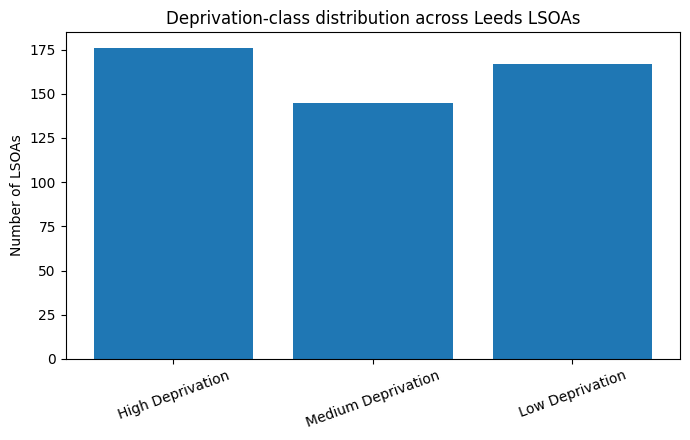

PASS: Every deprivation class is represented in every spatial fold.


In [13]:

preferred_class_order = [
    "High Deprivation",
    "Medium Deprivation",
    "Low Deprivation",
]
class_order = [
    class_name for class_name in preferred_class_order
    if class_name in set(df[TARGET_COL].dropna())
]

unexpected_classes = sorted(
    set(df[TARGET_COL].dropna()) - set(preferred_class_order)
)
if unexpected_classes:
    raise ValueError(f"Unexpected deprivation classes: {unexpected_classes}")

class_counts = (
    df[TARGET_COL]
    .value_counts()
    .reindex(class_order)
    .rename("n_lsoas")
    .to_frame()
)
class_counts["percent"] = 100 * class_counts["n_lsoas"] / len(df)

class_by_fold = pd.crosstab(
    df[FOLD_COL].astype(int),
    df[TARGET_COL],
).reindex(index=sorted(EXPECTED_FOLDS), columns=class_order, fill_value=0)

display(class_counts)
display(class_by_fold)

assert (class_counts["n_lsoas"] > 0).all()
assert (class_by_fold > 0).all().all()

fig, axis = plt.subplots(figsize=(7, 4.5))
axis.bar(class_counts.index, class_counts["n_lsoas"])
axis.set_title("Deprivation-class distribution across Leeds LSOAs")
axis.set_ylabel("Number of LSOAs")
axis.tick_params(axis="x", rotation=20)
fig.tight_layout()
class_plot_path = QA_FIGURE_DIR / "deprivation_class_balance.png"
fig.savefig(class_plot_path, dpi=220, bbox_inches="tight")
plt.show()

class_counts.to_csv(QA_DIR / "qa_class_balance_overall.csv")
class_by_fold.to_csv(QA_DIR / "qa_class_balance_by_fold.csv")

print("PASS: Every deprivation class is represented in every spatial fold.")



## 13. Image coverage per LSOA

Coverage is reviewed using the final number of successfully segmented images and the exported coverage category.

Zero LSOAs should be below the hard minimum. One LSOA may remain below the preferred threshold while still satisfying the minimum.


       n_images_segmented
count          488.000000
mean            39.696721
std              2.003649
min              4.000000
1%              32.000000
5%              40.000000
25%             40.000000
50%             40.000000
75%             40.000000
95%             40.000000
99%             40.000000
max             40.000000

              n_lsoas  total_images  mean_images  median_images  \
spatial_fold                                                      
1                  98          3860    39.387755           40.0   
2                  98          3888    39.673469           40.0   
3                  99          3948    39.878788           40.0   
4                  96          3812    39.708333           40.0   
5                  97          3864    39.835052           40.0   

              minimum_images  maximum_images  
spatial_fold                                  
1                          4              40  
2                         28              40  
3                         36              40  
4                         32              40  
5                         32              40  

                                n_lsoas
coverage_status                        
preferred_coverage                  487
acceptable_but_below_preferred        1

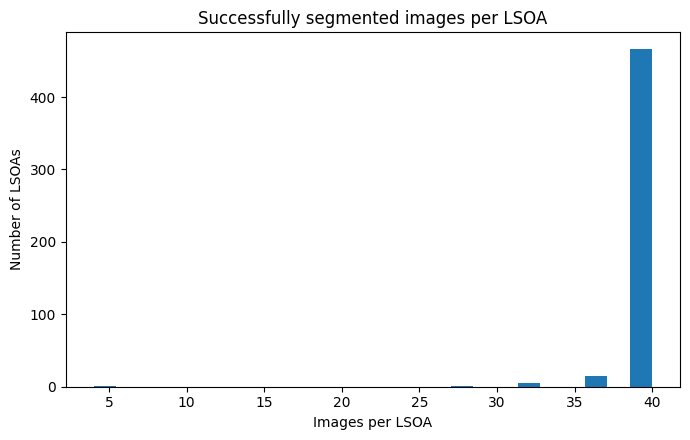

PASS: No LSOA is labelled below the minimum coverage threshold.


In [14]:

if "n_images_segmented" not in df.columns:
    raise KeyError("n_images_segmented is required for coverage QA.")

coverage_summary = df["n_images_segmented"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("n_images_segmented")

coverage_by_fold = df.groupby(FOLD_COL).agg(
    n_lsoas=(LSOA_ID_COL, "size"),
    total_images=("n_images_segmented", "sum"),
    mean_images=("n_images_segmented", "mean"),
    median_images=("n_images_segmented", "median"),
    minimum_images=("n_images_segmented", "min"),
    maximum_images=("n_images_segmented", "max"),
)

display(coverage_summary)
display(coverage_by_fold)

if "coverage_status" in df.columns:
    coverage_status = (
        df["coverage_status"]
        .value_counts(dropna=False)
        .rename_axis("coverage_status")
        .to_frame("n_lsoas")
    )
    display(coverage_status)
    coverage_status.to_csv(QA_DIR / "qa_coverage_status_counts.csv")

    below_minimum = int(
        df["coverage_status"].astype(str).eq("below_minimum").sum()
    )
else:
    coverage_status = pd.DataFrame()
    below_minimum = 0
    print("coverage_status column not found; hard-minimum status cannot be checked by label.")

fig, axis = plt.subplots(figsize=(7, 4.5))
axis.hist(df["n_images_segmented"], bins=25)
axis.set_title("Successfully segmented images per LSOA")
axis.set_xlabel("Images per LSOA")
axis.set_ylabel("Number of LSOAs")
fig.tight_layout()
coverage_plot_path = QA_FIGURE_DIR / "images_per_lsoa_distribution.png"
fig.savefig(coverage_plot_path, dpi=220, bbox_inches="tight")
plt.show()

coverage_summary.to_csv(QA_DIR / "qa_image_coverage_summary.csv")
coverage_by_fold.to_csv(QA_DIR / "qa_image_coverage_by_fold.csv")

assert below_minimum == 0
print("PASS: No LSOA is labelled below the minimum coverage threshold.")



## 14. Low-information imagery audit

The production run flagged only a small number of images. This section checks how those flags are distributed across LSOAs and prepares objective sensitivity-analysis counts without choosing a threshold based on model performance.


                                          result
lsoas_with_any_low_information_images  12.000000
lsoas_above_1_percent                  12.000000
lsoas_above_2_5_percent                 2.000000
lsoas_above_5_percent                   0.000000
maximum_low_information_fraction        0.050000
mean_low_information_fraction           0.000679

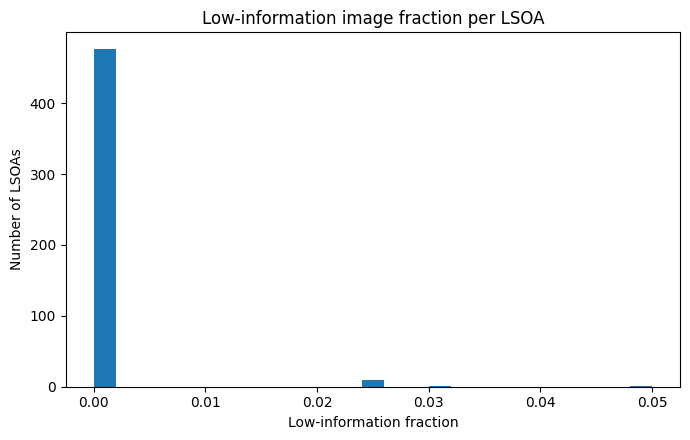

In [15]:

low_information_report = {}

if "low_information_fraction" in df.columns:
    low_fraction = pd.to_numeric(
        df["low_information_fraction"], errors="coerce"
    )

    low_information_report = {
        "lsoas_with_any_low_information_images": int((low_fraction > 0).sum()),
        "lsoas_above_1_percent": int((low_fraction > 0.01).sum()),
        "lsoas_above_2_5_percent": int((low_fraction > 0.025).sum()),
        "lsoas_above_5_percent": int((low_fraction > 0.05).sum()),
        "maximum_low_information_fraction": float(low_fraction.max()),
        "mean_low_information_fraction": float(low_fraction.mean()),
    }

    display(pd.Series(low_information_report, name="result").to_frame())

    fig, axis = plt.subplots(figsize=(7, 4.5))
    axis.hist(low_fraction, bins=25)
    axis.set_title("Low-information image fraction per LSOA")
    axis.set_xlabel("Low-information fraction")
    axis.set_ylabel("Number of LSOAs")
    fig.tight_layout()
    low_info_plot_path = QA_FIGURE_DIR / "low_information_fraction_distribution.png"
    fig.savefig(low_info_plot_path, dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("low_information_fraction is not available.")

pd.Series(low_information_report, name="value").to_csv(
    QA_DIR / "qa_low_information_summary.csv",
    header=True,
)



## 15. Spatial-fold quality

This section reads the frozen fold audits; it does not recreate or optimise the folds.


In [16]:

display(fold_audit)
display(fold_feature_balance)

fold_counts = df.groupby(FOLD_COL).agg(
    n_lsoas=(LSOA_ID_COL, "size"),
    n_images=("n_images_segmented", "sum"),
    n_blocks=(BLOCK_COL, "nunique"),
).sort_index()

def coefficient_of_variation(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="raise").to_numpy(dtype=float)
    return float(values.std(ddof=0) / values.mean())

lsoa_count_cv = coefficient_of_variation(fold_counts["n_lsoas"])
image_count_cv = coefficient_of_variation(fold_counts["n_images"])

if "max_abs_smd" in fold_feature_balance.columns:
    maximum_fold_feature_abs_smd = float(
        fold_feature_balance["max_abs_smd"].max()
    )
else:
    smd_candidate_columns = [
        c for c in fold_feature_balance.columns
        if c not in {FOLD_COL, "Unnamed: 0"}
    ]
    maximum_fold_feature_abs_smd = float(
        fold_feature_balance[smd_candidate_columns].abs().max().max()
    )

spatial_qa_metrics = pd.Series(
    {
        "n_folds": int(df[FOLD_COL].nunique()),
        "n_spatial_blocks": int(df[BLOCK_COL].nunique()),
        "fold_lsoa_count_cv": lsoa_count_cv,
        "fold_image_count_cv": image_count_cv,
        "maximum_fold_feature_abs_smd": maximum_fold_feature_abs_smd,
        "maximum_folds_per_lsoa": int(
            df.groupby(LSOA_ID_COL)[FOLD_COL].nunique().max()
        ),
        "maximum_folds_per_block": int(
            df.groupby(BLOCK_COL)[FOLD_COL].nunique().max()
        ),
    },
    name="result",
)

display(fold_counts)
display(spatial_qa_metrics.to_frame())

assert int(spatial_qa_metrics["n_folds"]) == 5
assert int(spatial_qa_metrics["maximum_folds_per_lsoa"]) == 1
assert int(spatial_qa_metrics["maximum_folds_per_block"]) == 1
assert lsoa_count_cv <= 0.05
assert image_count_cv <= 0.05
assert maximum_fold_feature_abs_smd <= 0.25

fold_counts.to_csv(QA_DIR / "qa_recomputed_fold_counts.csv")
spatial_qa_metrics.to_csv(
    QA_DIR / "qa_spatial_fold_quality_metrics.csv",
    header=True,
)

print("PASS: Frozen spatial folds satisfy the configured QA thresholds.")


   spatial_fold  n_lsoas  n_images  n_points  n_blocks  \
0             1       98      3860       965        25   
1             2       98      3888       972        22   
2             3       99      3948       987        22   
3             4       96      3812       953        27   
4             5       97      3864       966        24   

   images_High Deprivation  images_Low Deprivation  images_Medium Deprivation  \
0                     1356                    1348                       1156   
1                     1396                    1336                       1156   
2                     1480                    1316                       1152   
3                     1396                    1304                       1112   
4                     1400                    1308                       1156   

   lsoas_High Deprivation  lsoas_Low Deprivation  lsoas_Medium Deprivation  
0                      34                     34                        30  
1         

   spatial_fold  green_natural_mean  built_form_mean  pedestrian_realm_mean  \
0             1            0.029373         0.059264               0.090052   
1             2            0.020457         0.038236               0.029192   
2             3            0.166036         0.106730               0.077693   
3             4            0.110525         0.137025               0.007582   
4             5            0.009730         0.071824               0.048682   

   road_transport_mean  street_furniture_mean  active_travel_people_mean  \
0             0.213489               0.006069                   0.115581   
1             0.044843               0.013045                   0.042386   
2             0.062250               0.087953                   0.027091   
3             0.071959               0.109046                   0.051120   
4             0.035634               0.025204                   0.081354   

   sky_openness_mean  mean_segmentation_entropy  low_information_fra

              n_lsoas  n_images  n_blocks
spatial_fold                             
1                  98      3860        25
2                  98      3888        22
3                  99      3948        22
4                  96      3812        27
5                  97      3864        24

                                  result
n_folds                         5.000000
n_spatial_blocks              120.000000
fold_lsoa_count_cv              0.010449
fold_image_count_cv             0.011433
maximum_fold_feature_abs_smd    0.234264
maximum_folds_per_lsoa          1.000000
maximum_folds_per_block         1.000000

PASS: Frozen spatial folds satisfy the configured QA thresholds.



## 16. Target-leakage and modelling-column guardrails

This section identifies columns that must never be included automatically in the predictor matrix.


In [17]:

non_predictor_columns = [
    LSOA_ID_COL,
    "IMDRank",
    "IMDDecile",
    TARGET_COL,
    CLASS_INDEX_COL,
    FOLD_COL,
    BLOCK_COL,
    "x_km",
    "y_km",
    "lsoa_lat",
    "lsoa_lon",
]

existing_non_predictors = [c for c in non_predictor_columns if c in df.columns]

predictor_sets = {
    "raw_semantic_means": raw_semantic_features,
    "grouped_indicators": grouped_features,
    "clr_features": clr_features,
}

predictor_guardrail = pd.DataFrame(
    [
        {
            "predictor_set": set_name,
            "n_features": len(columns),
            "contains_target_or_identifier": bool(
                set(columns) & set(existing_non_predictors)
            ),
            "features": ", ".join(columns),
        }
        for set_name, columns in predictor_sets.items()
    ]
)

display(predictor_guardrail)

assert not predictor_guardrail["contains_target_or_identifier"].any()
predictor_guardrail.to_csv(
    QA_DIR / "qa_predictor_set_guardrails.csv",
    index=False,
)

print(
    "PASS: Predefined predictor representations contain no target, fold, "
    "identifier or coordinate columns."
)


        predictor_set  n_features  contains_target_or_identifier  \
0  raw_semantic_means          19                          False   
1  grouped_indicators           7                          False   
2        clr_features          19                          False   

                                            features  
0  seg_road_mean, seg_sidewalk_mean, seg_building...  
1  green_natural_mean, built_form_mean, pedestria...  
2  clr_road, clr_sidewalk, clr_building, clr_wall...  

PASS: Predefined predictor representations contain no target, fold, identifier or coordinate columns.



## 17. Final QA decision

The final decision is based on structural validity, finite values, semantic composition validity, class representation, coverage and frozen-fold integrity.

High correlation or VIF flags are documented as modelling considerations rather than automatic QA failures, because correlated variables may still be handled appropriately through representation choice and regularisation inside nested spatial CV.


In [18]:

missing_total = int(df.isna().sum().sum())
infinite_total = int(
    np.isinf(df[numeric_columns].to_numpy(dtype=float)).sum()
) if numeric_columns else 0

hard_checks = [
    {
        "criterion": "Expected one-row-per-LSOA dataset",
        "required_condition": f"{EXPECTED_LSOAS} rows and unique LSOAs",
        "observed_result": (
            f"{len(df)} rows; {df[LSOA_ID_COL].nunique()} unique LSOAs"
        ),
        "status": (
            "PASS"
            if len(df) == EXPECTED_LSOAS
            and df[LSOA_ID_COL].nunique() == EXPECTED_LSOAS
            else "FAIL"
        ),
    },
    {
        "criterion": "Duplicate LSOA identifiers",
        "required_condition": "0",
        "observed_result": str(int(df[LSOA_ID_COL].duplicated().sum())),
        "status": (
            "PASS" if df[LSOA_ID_COL].duplicated().sum() == 0 else "FAIL"
        ),
    },
    {
        "criterion": "Missing values",
        "required_condition": "0 or explicitly resolved before modelling",
        "observed_result": str(missing_total),
        "status": "PASS" if missing_total == 0 else "FAIL",
    },
    {
        "criterion": "Infinite numeric values",
        "required_condition": "0",
        "observed_result": str(infinite_total),
        "status": "PASS" if infinite_total == 0 else "FAIL",
    },
    {
        "criterion": "Raw semantic ranges",
        "required_condition": "All values between 0 and 1",
        "observed_result": f"min={semantic_min:.8f}; max={semantic_max:.8f}",
        "status": (
            "PASS"
            if semantic_min >= -SEMANTIC_SUM_TOLERANCE
            and semantic_max <= 1 + SEMANTIC_SUM_TOLERANCE
            else "FAIL"
        ),
    },
    {
        "criterion": "Semantic composition sums",
        "required_condition": "Approximately 1 for every LSOA",
        "observed_result": (
            f"maximum absolute error="
            f"{np.abs(semantic_sum - 1.0).max():.3e}"
        ),
        "status": (
            "PASS"
            if np.allclose(
                semantic_sum.to_numpy(),
                1.0,
                atol=SEMANTIC_SUM_TOLERANCE,
                rtol=0,
            )
            else "FAIL"
        ),
    },
    {
        "criterion": "All classes represented in every fold",
        "required_condition": "All cells > 0",
        "observed_result": (
            f"minimum class-by-fold count={int(class_by_fold.min().min())}"
        ),
        "status": "PASS" if (class_by_fold > 0).all().all() else "FAIL",
    },
    {
        "criterion": "LSOA and block leakage",
        "required_condition": "One fold per LSOA and one fold per block",
        "observed_result": (
            f"max folds/LSOA="
            f"{df.groupby(LSOA_ID_COL)[FOLD_COL].nunique().max()}; "
            f"max folds/block="
            f"{df.groupby(BLOCK_COL)[FOLD_COL].nunique().max()}"
        ),
        "status": (
            "PASS"
            if df.groupby(LSOA_ID_COL)[FOLD_COL].nunique().max() == 1
            and df.groupby(BLOCK_COL)[FOLD_COL].nunique().max() == 1
            else "FAIL"
        ),
    },
    {
        "criterion": "Minimum image coverage",
        "required_condition": "0 LSOAs below minimum",
        "observed_result": str(below_minimum),
        "status": "PASS" if below_minimum == 0 else "FAIL",
    },
    {
        "criterion": "Fold-size balance",
        "required_condition": "LSOA and image CV <= 0.05",
        "observed_result": (
            f"LSOA CV={lsoa_count_cv:.6f}; "
            f"image CV={image_count_cv:.6f}"
        ),
        "status": (
            "PASS"
            if lsoa_count_cv <= 0.05 and image_count_cv <= 0.05
            else "FAIL"
        ),
    },
    {
        "criterion": "Fold feature balance",
        "required_condition": "Maximum absolute SMD <= 0.25",
        "observed_result": f"{maximum_fold_feature_abs_smd:.6f}",
        "status": (
            "PASS"
            if maximum_fold_feature_abs_smd <= 0.25
            else "FAIL"
        ),
    },
]

qa_decision_table = pd.DataFrame(hard_checks)
display(qa_decision_table)

overall_pass = bool((qa_decision_table["status"] == "PASS").all())
qa_decision = (
    "APPROVED FOR NESTED SPATIAL MODELLING"
    if overall_pass
    else "MODELLING PAUSED — CORRECT FAILED QA ITEMS"
)

print("\nFINAL QA DECISION:", qa_decision)

qa_decision_table.to_csv(QA_DIR / "qa_final_decision_table.csv", index=False)


                                criterion  \
0       Expected one-row-per-LSOA dataset   
1              Duplicate LSOA identifiers   
2                          Missing values   
3                 Infinite numeric values   
4                     Raw semantic ranges   
5               Semantic composition sums   
6   All classes represented in every fold   
7                  LSOA and block leakage   
8                  Minimum image coverage   
9                       Fold-size balance   
10                   Fold feature balance   

                           required_condition  \
0                   488 rows and unique LSOAs   
1                                           0   
2   0 or explicitly resolved before modelling   
3                                           0   
4                  All values between 0 and 1   
5              Approximately 1 for every LSOA   
6                               All cells > 0   
7    One fold per LSOA and one fold per block   
8                 


FINAL QA DECISION: APPROVED FOR NESTED SPATIAL MODELLING



## 18. Save machine-readable QA summary


In [19]:

qa_summary = {
    "qa_decision": qa_decision,
    "approved_for_modelling": overall_pass,
    "lsoa_feature_file": str(LSOA_FEATURE_FILE),
    "lsoa_feature_file_sha256": sha256_file(LSOA_FEATURE_FILE),
    "fold_map_file": str(FOLD_MAP_FILE),
    "fold_map_file_sha256": sha256_file(FOLD_MAP_FILE),
    "rows": int(len(df)),
    "columns": int(df.shape[1]),
    "unique_lsoas": int(df[LSOA_ID_COL].nunique()),
    "missing_values_total": missing_total,
    "infinite_values_total": infinite_total,
    "duplicate_lsoa_ids": int(df[LSOA_ID_COL].duplicated().sum()),
    "raw_semantic_features": len(raw_semantic_features),
    "grouped_features": len(grouped_features),
    "clr_features": len(clr_features),
    "semantic_sum_maximum_absolute_error": float(
        np.abs(semantic_sum - 1.0).max()
    ),
    "class_counts": {
        str(index): int(value)
        for index, value in class_counts["n_lsoas"].items()
    },
    "spatial_blocks": int(df[BLOCK_COL].nunique()),
    "spatial_folds": sorted(df[FOLD_COL].astype(int).unique().tolist()),
    "fold_lsoa_count_cv": float(lsoa_count_cv),
    "fold_image_count_cv": float(image_count_cv),
    "maximum_fold_feature_abs_smd": float(
        maximum_fold_feature_abs_smd
    ),
    "lsoas_below_minimum_coverage": int(below_minimum),
    "constant_candidate_predictors": constant_features,
    "high_correlation_pairs_at_abs_0_90": int(
        len(flagged_correlations)
    ),
    "grouped_indicators_with_vif_above_10": grouped_vif.loc[
        grouped_vif["flag_vif_above_10"], "feature"
    ].tolist(),
    "qa_output_directory": str(QA_DIR),
}

with (QA_DIR / "qa_summary.json").open("w", encoding="utf-8") as file:
    json.dump(qa_summary, file, indent=2)

print(json.dumps(qa_summary, indent=2))
print("\nSaved all QA outputs to:", QA_DIR)


{
  "qa_decision": "APPROVED FOR NESTED SPATIAL MODELLING",
  "approved_for_modelling": true,
  "lsoa_feature_file": "<PROJECT_DIR>/outputs_10points_metadata_once/segmentation_lsoa_features_19class_mean_sd.csv",
  "lsoa_feature_file_sha256": "dc981747a7a7f884f623b2d4a396ec18adc2eaa96e551649f8aae297446e10e3",
  "fold_map_file": "<PROJECT_DIR>/outputs_10points_metadata_once/lsoa_spatial_plus_fold_mapping.csv",
  "fold_map_file_sha256": "7b83dba8bdb805a08e09da5cda2f135e875a727d5dedac7a36bf442d60570abe",
  "rows": 488,
  "columns": 102,
  "unique_lsoas": 488,
  "missing_values_total": 0,
  "infinite_values_total": 0,
  "duplicate_lsoa_ids": 0,
  "raw_semantic_features": 19,
  "grouped_features": 7,
  "clr_features": 19,
  "semantic_sum_maximum_absolute_error": 9.992007221626409e-16,
  "class_counts": {
    "High Deprivation": 176,
    "Medium Deprivation": 145,
    "Low Deprivation": 167
  },
  "spatial_blocks": 120,
  "spatial_folds": [
    1,
    2,
    3,
    4,
    5
  ],
  "fold_lsoa_


# Interpretation and next step

When the final decision is **APPROVED FOR NESTED SPATIAL MODELLING**:

1. Freeze the LSOA feature table and spatial fold map.
2. Preserve the recorded SHA-256 checksums.
3. Use one LSOA per modelling row.
4. Keep the five exported spatial folds unchanged for every model.
5. Fit imputation, scaling, PCA, feature selection, class weighting, calibration and hyperparameter tuning only within the training partitions of nested spatial cross-validation.
6. Compare grouped indicators, raw semantic proportions and CLR features as separate predictor representations.
7. Use macro-F1 as the primary selection metric and report balanced accuracy, class-specific metrics, confusion matrices and variability across outer folds.
8. Compute Moran's I from out-of-fold errors or residuals after all five outer folds have been evaluated.
